# AI-Based Diabetes Prediction System
Infosys Internship Minor Project

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load DataSet
df = pd.read_csv('diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
#Dataset Description
print('=====Information=====')
df.info()
print('\n\n=====Describe=====')
print(df.describe())
print('\n\n=====Null Values=====')
df.isnull().sum()

=====Information=====
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB


=====Describe=====
                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315  

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

## Data Visualization

- The countplot shows the distribution of the target variable `diabetes`.
- 0 represents non-diabetic patients.
- 1 represents diabetic patients.
- The dataset appears to be imbalanced (as counts are unequal).
- This imbalance may affect model performance.

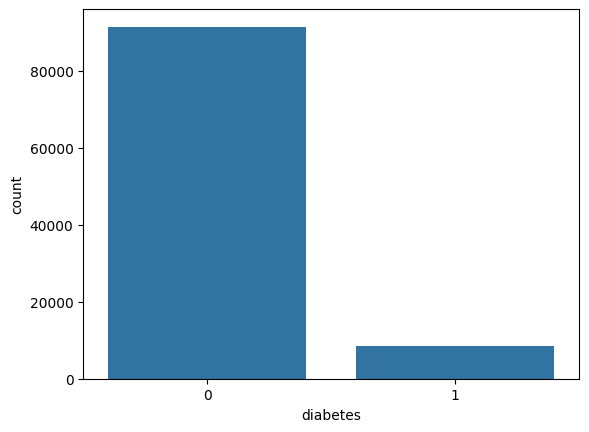


Exact numbers :
 diabetes
0    91500
1     8500
Name: count, dtype: int64


In [4]:
#Data Visualization
sns.countplot(x='diabetes', data=df)
plt.show()
print('\nExact numbers :\n', df['diabetes'].value_counts())

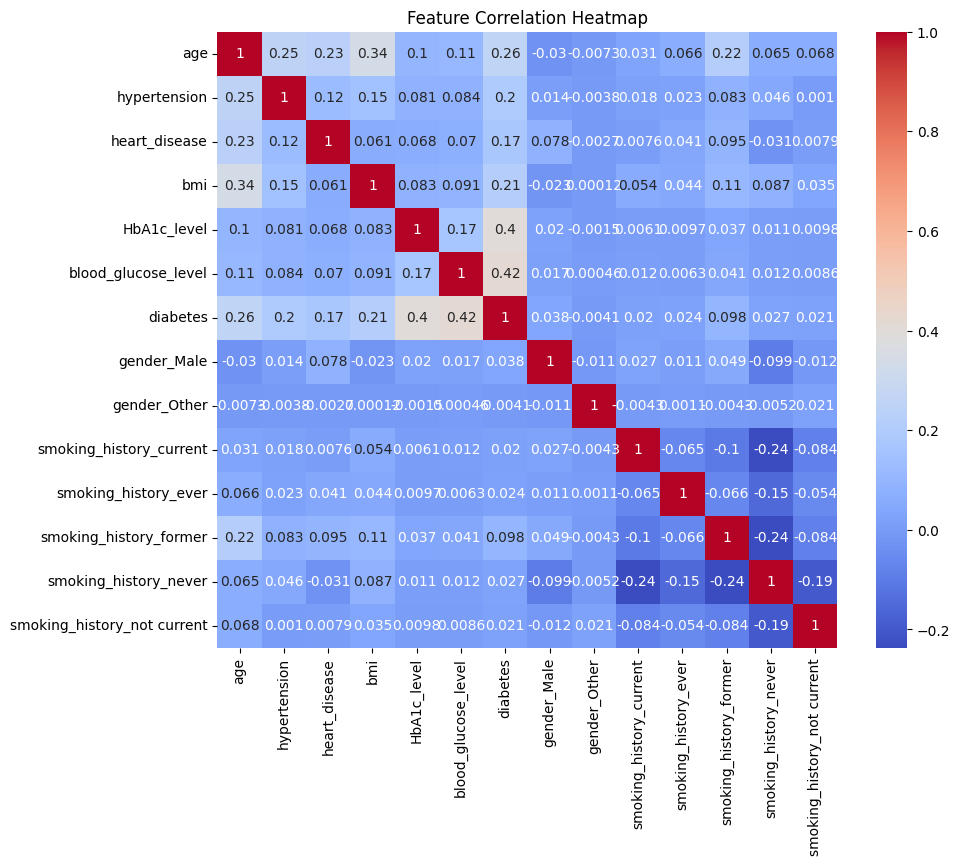

In [19]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## Class Imbalance

- The dataset is imbalanced:
  - 91.5% non-diabetic (0)
  - 8.5% diabetic (1)
- This imbalance can lead to biased model predictions.
- Accuracy alone is not sufficient to evaluate performance.
- Additional metrics like precision, recall, and F1-score are needed.

In [5]:
##Data Preprocessing
# Unique Values
print(df['gender'].unique())
print(df['smoking_history'].unique())

<ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
<ArrowStringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str


In [6]:
#Enoding categorical data (using one-hot encoding)
df = pd.get_dummies(df, columns=['gender', 'smoking_history'], drop_first=True)
df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False


In [7]:
#Split:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [8]:
#Train-Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (80000, 13)
Testing size: (20000, 13)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Data Preprocessing

- Categorical variables (`gender`, `smoking_history`) were converted using one-hot encoding.
- The dataset was split into training and testing sets (80:20 ratio).
- Feature scaling was applied using StandardScaler to normalize numerical values.

In [14]:
#Model training
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Model Improvement Analysis

- Applying class_weight='balanced' did not significantly improve recall.
- This indicates that the model was already performing well.
- Further improvement may require advanced techniques like SMOTE or hyperparameter tuning.

In [15]:
# Prediction
y_pred = model.predict(X_test)

In [25]:
#Model Evaluation
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.96935
Confusion Matrix:
[[18215    77]
 [  536  1172]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.94      0.69      0.79      1708

    accuracy                           0.97     20000
   macro avg       0.95      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



## Model Evaluation

- The model achieved an overall accuracy of 97%.
- However, the dataset is imbalanced, so accuracy alone is not sufficient.
- The recall for diabetic patients (class 1) is 0.69, meaning some cases are missed.
- In medical applications, recall is important to minimize false negatives.

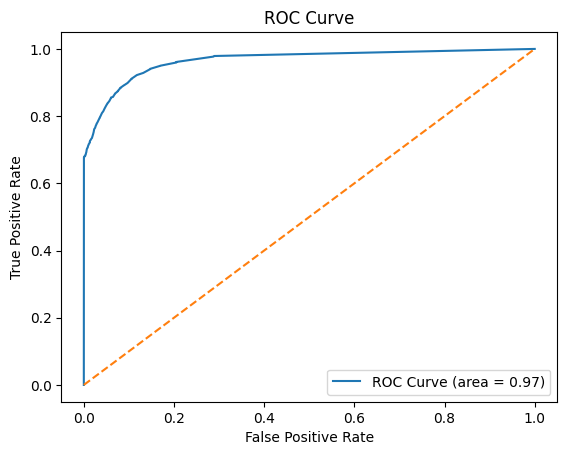

In [18]:
#ROC Curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## ROC-AUC Curve

- ROC curve shows the trade-off between sensitivity and specificity.
- AUC (Area Under Curve) represents model performance.
- Higher AUC indicates better classification ability.

## ROC-AUC Analysis

- The model achieved an AUC score of 0.97.
- This indicates excellent performance in distinguishing between diabetic and non-diabetic cases.
- The ROC curve is close to the top-left corner, showing high sensitivity and specificity.

In [20]:
#Prediction System:
def predict_diabetes(input_data):
    input_df = pd.DataFrame([input_data])
    
    # Apply same encoding
    input_df = pd.get_dummies(input_df)
    
    # Align columns with training data
    input_df = input_df.reindex(columns=X.columns, fill_value=0)
    
    # Scale
    input_scaled = scaler.transform(input_df)
    
    # Predict
    prediction = model.predict(input_scaled)
    probability = model.predict_proba(input_scaled)[0][1]
    
    if prediction[0] == 1:
        return f"Diabetic (Risk: {probability:.2f})"
    else:
        return f"Non-Diabetic (Risk: {probability:.2f})"

In [ ]:
#User Input & Prediction Interface
# 1st sample 
  #Borderline / moderate sample; Not strongly diabetic
sample = {
    'age': 50,
    'hypertension': 0,
    'heart_disease': 0,
    'bmi': 28.5,
    'HbA1c_level': 6.5,
    'blood_glucose_level': 140,
    'gender_Male': 1,
    'gender_Other': 0,
    'smoking_history_current': 0,
    'smoking_history_ever': 0,
    'smoking_history_former': 1,
    'smoking_history_never': 0,
    'smoking_history_not current': 0
}

print(predict_diabetes(sample))

Non-Diabetic (Risk: 0.04)


In [ ]:
# 2nd sample
  #high-risk sample
sample = {
    'age': 65,
    'hypertension': 1,
    'heart_disease': 1,
    'bmi': 35,
    'HbA1c_level': 8.5,
    'blood_glucose_level': 250,
    'gender_Male': 1,
    'gender_Other': 0,
    'smoking_history_current': 1,
    'smoking_history_ever': 0,
    'smoking_history_former': 0,
    'smoking_history_never': 0,
    'smoking_history_not current': 0
}

print(predict_diabetes(sample))

Diabetic (Risk: 1.00)


## Conclusion

- A machine learning model was developed to predict diabetes using health-related features.
- Random Forest Classifier achieved high accuracy and strong ROC-AUC score (0.97).
- The model performs well in identifying diabetic patients, though some false negatives remain.
- This system can assist in early detection and preventive healthcare.